# Loan Approval Prediction Notebook

This is a notebook for a machine learning analysis of a loan approval dataset.

Firstly, we mount drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Then we load the data.

In [ ]:
import pandas as pd
loan = pd.read_csv('/content/drive/MyDrive/Data science/Data/Loan Approval Prediction.csv')
loan.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


## Exploratory Analysis

Next we do a pivot table of the data's Person Income variable by the Education variable.

In [ ]:
loan_pivot = pd.pivot_table(data = loan, values = 'Person Income', columns = 'Education', aggfunc = 'mean')
loan_pivot.head()

Education,Associate,Bachelor,Doctorate,High School,Master
Person Income,80641.623628,79703.319725,87234.541063,80224.597645,80491.924355


It seems there is little variability of income by education in this dataset. Now we do more pivot tables of Income by gender, home ownership situation and loan intent.

In [ ]:
loan_pivot2 = pd.pivot_table(data = loan, values = 'Person Income', columns = 'Gender', aggfunc = 'mean')
loan_pivot2.head()

Gender,female,male
Person Income,79410.904856,81056.034942


In [ ]:
loan_pivot3 = pd.pivot_table(data = loan, values = 'Person Income', columns = 'Home Onwership', aggfunc = 'mean')
loan_pivot3.head()

Home Onwership,MORTGAGE,OTHER,OWN,RENT
Person Income,101569.307751,91480.068376,68423.409353,65001.143838


In [ ]:
loan_pivot4 = pd.pivot_table(data = loan, values = 'Person Income', columns = 'Loan Intent', aggfunc = 'mean')
loan_pivot4.head()

Loan Intent,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
Person Income,80608.216935,77765.025019,89148.745766,73414.8719,83030.910222,82571.965852


It seems there is some more variation in this data. Let's keep looking. This time, with bar graphs.

In [ ]:
import matplotlib.pyplot as plt

We will plot the histogram of income, filtering very high income.

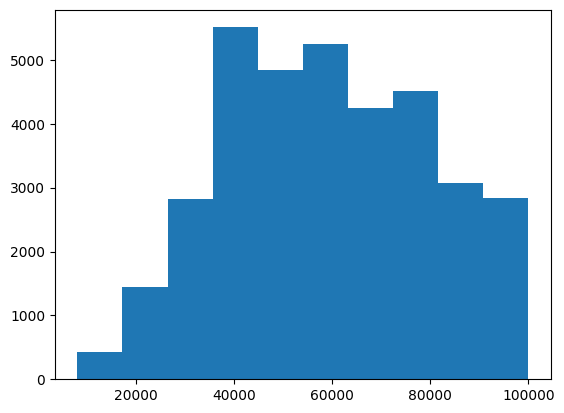

In [ ]:
loan = loan[loan['Person Income'] < 100000]
plt.hist(loan['Person Income'])
plt.show()

Now we plot the histogram of loan amount.

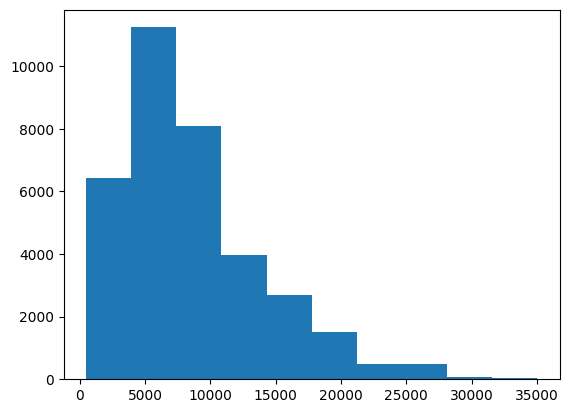

In [ ]:
plt.hist(loan['Loan Amount'])
plt.show()

In [ ]:
It follows a chi-squared distribution.

And the histogram of credit score.

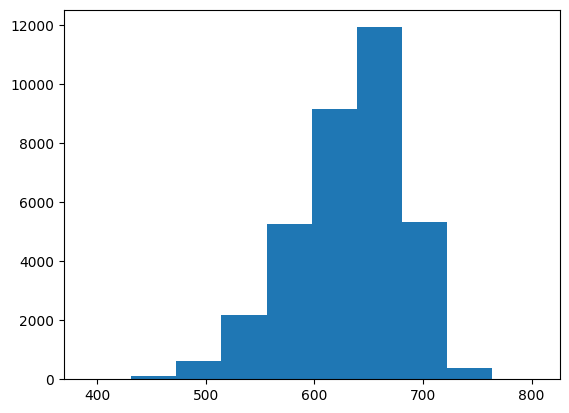

In [ ]:
plt.hist(loan['Credit Score'])
plt.show()

It follows roughly a normal distribution.

And how many years of employee experience, filtering the outliers.

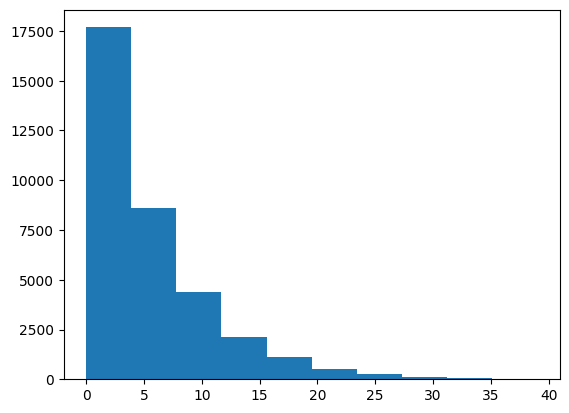

In [ ]:
loan = loan[loan['Employee Experience'] < 40]
plt.hist(loan['Employee Experience'])
plt.show()

It follows an exponential distribution.

Now we plot the loan interest rate.

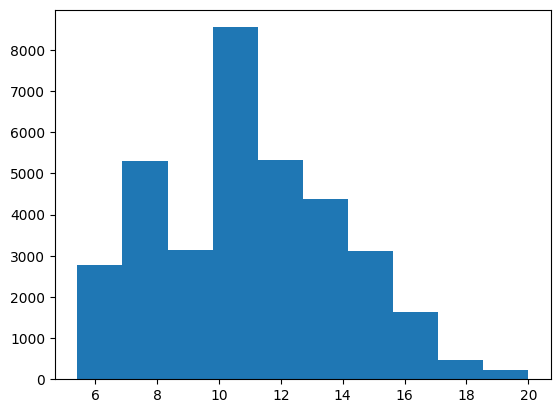

In [ ]:
plt.hist(loan['Loan interest Rate'])
plt.show()

It follows roughly a bimodal distribution.

Now we plot our target variable (Loan Status) against other variables.

In [ ]:
import numpy as np
loan['Loan Status'] = np.where(loan['Loan Status'] == 0, 'Rejected', 'Approved')

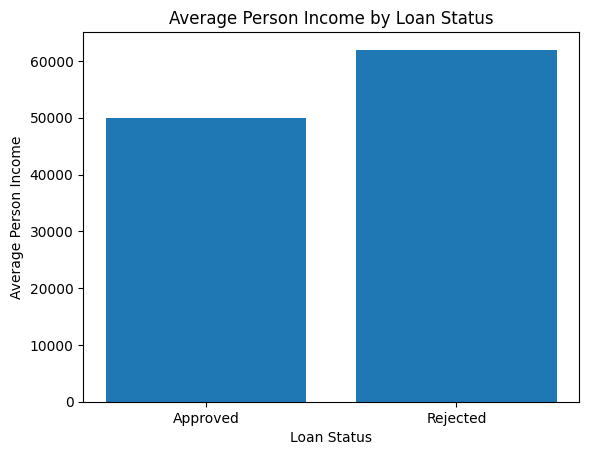

In [ ]:
avg_income_by_status = loan.groupby('Loan Status')['Person Income'].mean().reset_index()

plt.bar(x = avg_income_by_status['Loan Status'], height = avg_income_by_status['Person Income'])
plt.xlabel('Loan Status')
plt.ylabel('Average Person Income')
plt.title('Average Person Income by Loan Status')
plt.show()

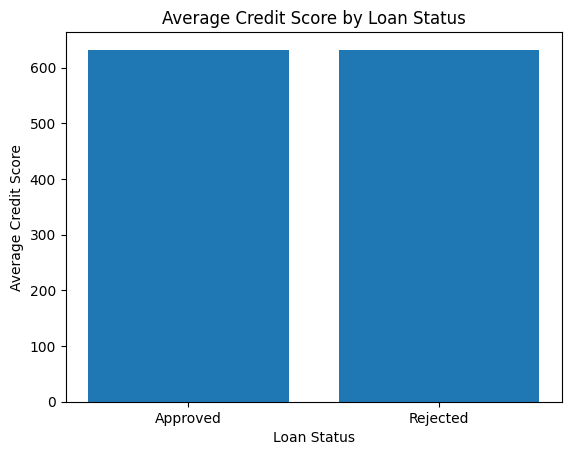

In [ ]:
avg_credit_score_by_status = loan.groupby('Loan Status')['Credit Score'].mean().reset_index()
plt.bar(x = avg_credit_score_by_status['Loan Status'], height = avg_credit_score_by_status['Credit Score'])
plt.xlabel('Loan Status')
plt.ylabel('Average Credit Score')
plt.title('Average Credit Score by Loan Status')
plt.show()

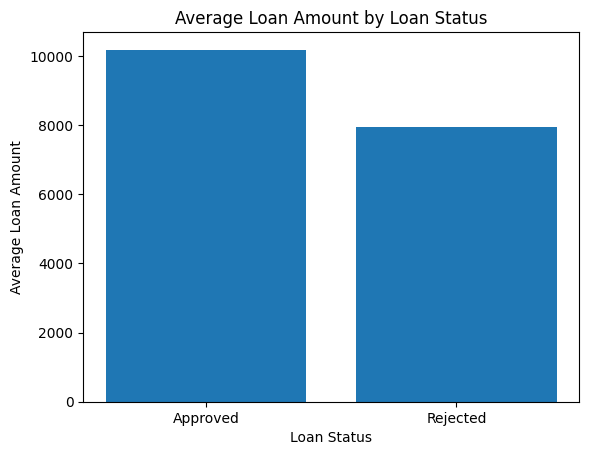

In [ ]:
avg_loan_amount_by_status = loan.groupby('Loan Status')['Loan Amount'].mean().reset_index()
plt.bar(x = avg_loan_amount_by_status['Loan Status'], height = avg_loan_amount_by_status['Loan Amount'])
plt.xlabel('Loan Status')
plt.ylabel('Average Loan Amount')
plt.title('Average Loan Amount by Loan Status')
plt.show()

By these descriptive statistics and plots, we consider that there are puzzling elements to this data. Average loan amount is bigger for those whose order is approved, as well as virtually no difference between avergae credit scores between those that are accepted and not accepted. And the income of those with rejected loans is bigger than of those that are accepted. Nevertheless we will try to fit some predictive models.

## Predictive Analysis

Firstly we will fit a XGBoost algorithm to this data.

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
X, y = loan.drop('Loan Status', axis = 1), loan['Loan Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert 'Loan Status' to numerical labels (0 and 1)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Identify categorical columns for one-hot encoding
categorical_cols = X_train.select_dtypes(include='object').columns

# Apply one-hot encoding to training and testing sets
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial for consistency between train and test sets
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Initialize XGBoost classifier
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=10)

# Train the model
model.fit(X_train_encoded, y_train_encoded)

# Make predictions on the test set
y_pred = model.predict(X_test_encoded)

# Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:55:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9224


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Calculate Precision, Recall, and F1-score
precision = precision_score(y_test_encoded, y_pred)
recall = recall_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# You can also print a full classification report for more details
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred))

Precision: 0.9349
Recall: 0.9615
F1-score: 0.9480

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1845
           1       0.93      0.96      0.95      5141

    accuracy                           0.92      6986
   macro avg       0.91      0.89      0.90      6986
weighted avg       0.92      0.92      0.92      6986



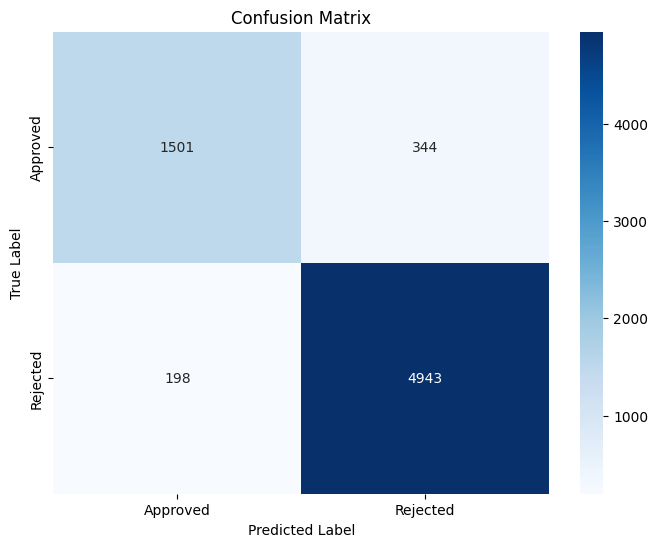

In [ ]:
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

We got good prediction statistics, as well as a good confusion matrix. We move on to testing other models, albeit this algorithm was already a good fit.

Random Forest Accuracy: 0.9165
Random Forest Precision: 0.9260
Random Forest Recall: 0.9636
Random Forest F1-score: 0.9444

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.79      0.83      1845
           1       0.93      0.96      0.94      5141

    accuracy                           0.92      6986
   macro avg       0.91      0.87      0.89      6986
weighted avg       0.92      0.92      0.91      6986



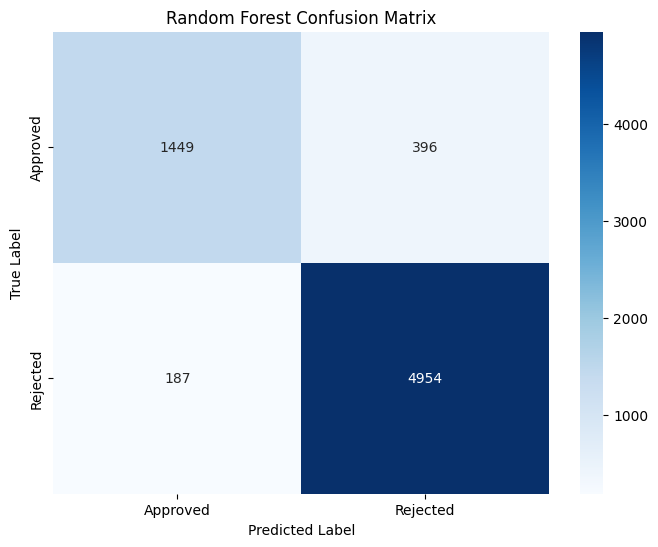

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest classifier
rf_model = RandomForestClassifier(random_state=10)

# Train the model
rf_model.fit(X_train_encoded, y_train_encoded)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_encoded)

# Evaluate the model
accuracy_rf = accuracy_score(y_test_encoded, y_pred_rf)
precision_rf = precision_score(y_test_encoded, y_pred_rf)
recall_rf = recall_score(y_test_encoded, y_pred_rf)
f1_rf = f1_score(y_test_encoded, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-score: {f1_rf:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test_encoded, y_pred_rf))

# Plot the confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test_encoded, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

We also get a good fit here. Let's try deep learning next.


Neural Network Accuracy: 0.7559
Neural Network Precision: 0.7510
Neural Network Recall: 0.9998
Neural Network F1-score: 0.8577

Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.08      0.14      1845
           1       0.75      1.00      0.86      5141

    accuracy                           0.76      6986
   macro avg       0.87      0.54      0.50      6986
weighted avg       0.81      0.76      0.67      6986



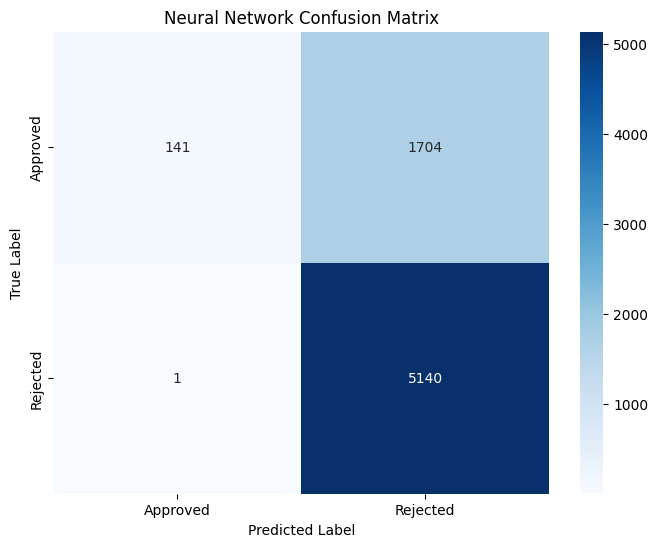

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_encoded.astype(float).values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.float32).unsqueeze(1) # Unsqueeze for BCEWithLogitsLoss
X_test_tensor = torch.tensor(X_test_encoded.astype(float).values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.float32).unsqueeze(1) # Unsqueeze for BCEWithLogitsLoss

# Create DataLoader for batching
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Define the Neural Network model
class NeuralNet(nn.Module):
    def __init__(self, input_size):
        super(NeuralNet, self).__init__()
        self.layer_1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.layer_2 = nn.Linear(128, 64)
        self.layer_out = nn.Linear(64, 1)

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.layer_out(x)
        return x

# Initialize the model
input_size = X_train_encoded.shape[1]
model_nn = NeuralNet(input_size)

# Define Loss function and Optimizer
criterion = nn.BCEWithLogitsLoss() # Combines Sigmoid and BCELoss
optimizer = optim.Adam(model_nn.parameters(), lr=0.001)

# Train the model
num_epochs = 20
for epoch in range(num_epochs):
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_nn(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    # print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}') # Optional: print loss per epoch

# Make predictions on the test set
model_nn.eval() # Set model to evaluation mode
with torch.no_grad():
    y_pred_proba_nn = torch.sigmoid(model_nn(X_test_tensor))
    y_pred_nn = (y_pred_proba_nn > 0.5).int().numpy() # Convert probabilities to binary predictions

# Evaluate the model
accuracy_nn = accuracy_score(y_test_encoded, y_pred_nn)
precision_nn = precision_score(y_test_encoded, y_pred_nn)
recall_nn = recall_score(y_test_encoded, y_pred_nn)
f1_nn = f1_score(y_test_encoded, y_pred_nn)

print(f"\nNeural Network Accuracy: {accuracy_nn:.4f}")
print(f"Neural Network Precision: {precision_nn:.4f}")
print(f"Neural Network Recall: {recall_nn:.4f}")
print(f"Neural Network F1-score: {f1_nn:.4f}")

print("\nNeural Network Classification Report:")
print(classification_report(y_test_encoded, y_pred_nn))

# Plot the confusion matrix for Neural Network
cm_nn = confusion_matrix(y_test_encoded, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Neural Network Confusion Matrix')
plt.show()

The neural network has considerably lower performance than the previous models.

Now we will try Discriminant Analysis and Naive Bayes.


--- Linear Discriminant Analysis (LDA) ---
LDA Accuracy: 0.8803
LDA Precision: 0.9215
LDA Recall: 0.9154
LDA F1-score: 0.9184

LDA Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      1845
           1       0.92      0.92      0.92      5141

    accuracy                           0.88      6986
   macro avg       0.84      0.85      0.85      6986
weighted avg       0.88      0.88      0.88      6986



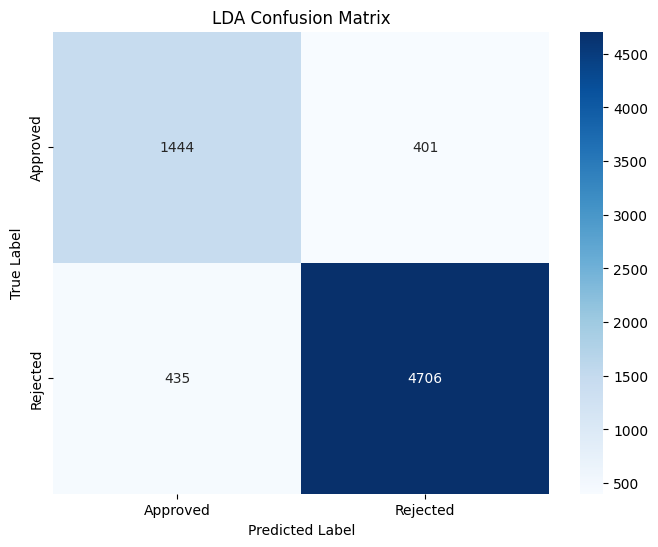


--- Quadratic Discriminant Analysis (QDA) ---
QDA Accuracy: 0.8102
QDA Precision: 0.9760
QDA Recall: 0.7607
QDA F1-score: 0.8551

QDA Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.95      0.73      1845
           1       0.98      0.76      0.86      5141

    accuracy                           0.81      6986
   macro avg       0.78      0.85      0.79      6986
weighted avg       0.87      0.81      0.82      6986



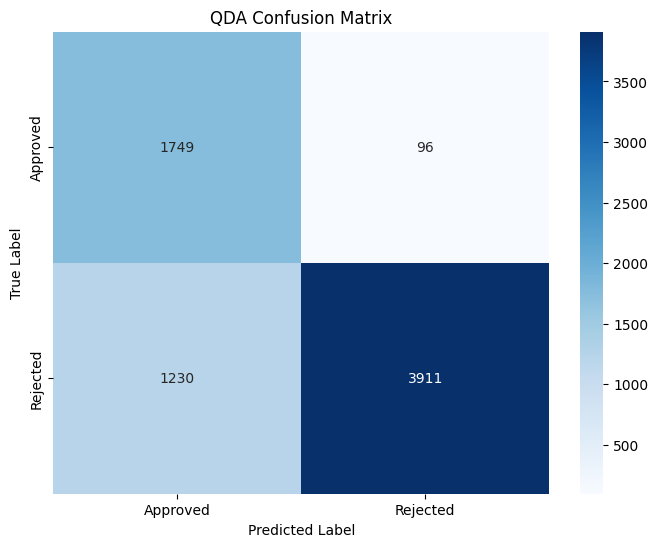

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# --- Linear Discriminant Analysis (LDA) ---
print("\n--- Linear Discriminant Analysis (LDA) ---")

# Initialize LDA model
lda_model = LinearDiscriminantAnalysis()

# Train the model
lda_model.fit(X_train_encoded, y_train_encoded)

# Make predictions on the test set
y_pred_lda = lda_model.predict(X_test_encoded)

# Evaluate the model
accuracy_lda = accuracy_score(y_test_encoded, y_pred_lda)
precision_lda = precision_score(y_test_encoded, y_pred_lda)
recall_lda = recall_score(y_test_encoded, y_pred_lda)
f1_lda = f1_score(y_test_encoded, y_pred_lda)

print(f"LDA Accuracy: {accuracy_lda:.4f}")
print(f"LDA Precision: {precision_lda:.4f}")
print(f"LDA Recall: {recall_lda:.4f}")
print(f"LDA F1-score: {f1_lda:.4f}")

print("\nLDA Classification Report:")
print(classification_report(y_test_encoded, y_pred_lda))

# Plot the confusion matrix for LDA
cm_lda = confusion_matrix(y_test_encoded, y_pred_lda)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LDA Confusion Matrix')
plt.show()

# --- Quadratic Discriminant Analysis (QDA) ---
print("\n--- Quadratic Discriminant Analysis (QDA) ---")

# Initialize QDA model
qda_model = QuadraticDiscriminantAnalysis()

# Train the model
qda_model.fit(X_train_encoded, y_train_encoded)

# Make predictions on the test set
y_pred_qda = qda_model.predict(X_test_encoded)

# Evaluate the model
accuracy_qda = accuracy_score(y_test_encoded, y_pred_qda)
precision_qda = precision_score(y_test_encoded, y_pred_qda)
recall_qda = recall_score(y_test_encoded, y_pred_qda)
f1_qda = f1_score(y_test_encoded, y_pred_qda)

print(f"QDA Accuracy: {accuracy_qda:.4f}")
print(f"QDA Precision: {precision_qda:.4f}")
print(f"QDA Recall: {recall_qda:.4f}")
print(f"QDA F1-score: {f1_qda:.4f}")

print("\nQDA Classification Report:")
print(classification_report(y_test_encoded, y_pred_qda))

# Plot the confusion matrix for QDA
cm_qda = confusion_matrix(y_test_encoded, y_pred_qda)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('QDA Confusion Matrix')
plt.show()


--- Naive Bayes ---
Naive Bayes Accuracy: 0.8453
Naive Bayes Precision: 0.8643
Naive Bayes Recall: 0.9368
Naive Bayes F1-score: 0.8991

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.59      0.67      1845
           1       0.86      0.94      0.90      5141

    accuracy                           0.85      6986
   macro avg       0.82      0.76      0.78      6986
weighted avg       0.84      0.85      0.84      6986



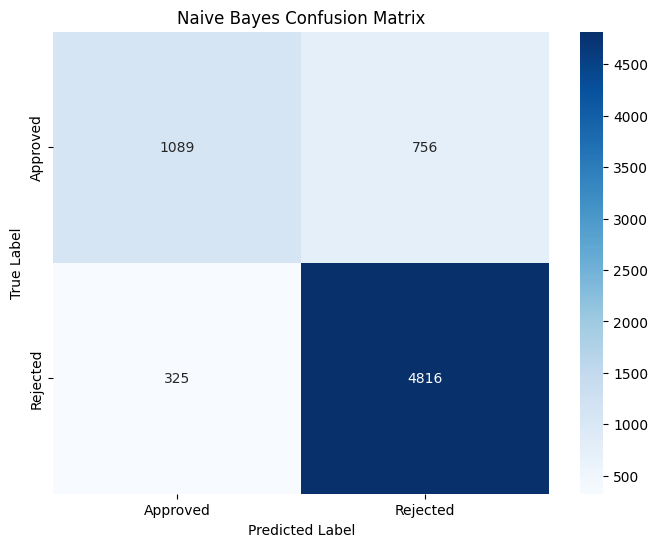

In [ ]:
from sklearn.naive_bayes import GaussianNB

# --- Naive Bayes ---
print("\n--- Naive Bayes ---")

# Initialize Gaussian Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train_encoded, y_train_encoded)

# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test_encoded)

# Evaluate the model
accuracy_nb = accuracy_score(y_test_encoded, y_pred_nb)
precision_nb = precision_score(y_test_encoded, y_pred_nb)
recall_nb = recall_score(y_test_encoded, y_pred_nb)
f1_nb = f1_score(y_test_encoded, y_pred_nb)

print(f"Naive Bayes Accuracy: {accuracy_nb:.4f}")
print(f"Naive Bayes Precision: {precision_nb:.4f}")
print(f"Naive Bayes Recall: {recall_nb:.4f}")
print(f"Naive Bayes F1-score: {f1_nb:.4f}")

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test_encoded, y_pred_nb))

# Plot the confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test_encoded, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

All these models have acceptable prediction statistics. However, XGBoost and Random Forest remain the best models. We will choose XGBoost because it is slightly better by prediction statistics, albeit the difference is really small.